#### Asumimos la extracción de términos más sencilla:

In [31]:
import re

FILE_PATH = "test_data/pg2000.txt"

dfs = {}

try:
    with open(FILE_PATH, 'r', encoding='utf-8') as f:
        words = re.findall(r'[a-z]+', f.read().lower())
        for word in words:
            dfs[word] = dfs.get(word, 0) + 1
except Exception as e:
    print(f"Error al leer el archivo '{FILE_PATH}': {e}")

dfs = sorted(dfs.items(), key=lambda x: x[1], reverse=True)

print(dfs)

[('que', 20769), ('de', 18411), ('y', 18280), ('a', 15700), ('la', 10528), ('en', 8295), ('el', 8271), ('se', 7035), ('no', 6397), ('los', 4776), ('con', 4275), ('n', 4195), ('s', 4130), ('por', 3945), ('lo', 3707), ('le', 3702), ('las', 3492), ('su', 3389), ('m', 3150), ('don', 2718), ('del', 2536), ('me', 2405), ('o', 2333), ('como', 2270), ('quijote', 2245), ('sancho', 2174), ('es', 2166), ('yo', 2077), ('si', 1979), ('un', 1943), ('as', 1897), ('al', 1843), ('dijo', 1808), ('l', 1715), ('mi', 1706), ('para', 1467), ('ser', 1460), ('hab', 1435), ('ni', 1434), ('porque', 1395), ('una', 1334), ('tan', 1245), ('or', 1193), ('todo', 1181), ('sin', 1159), ('d', 1152), ('respondi', 1079), ('ha', 1052), ('sus', 1051), ('bien', 1051), ('pero', 1015), ('an', 972), ('merced', 900), ('qu', 888), ('esto', 886), ('pues', 865), ('vuestra', 852), ('todos', 818), ('ya', 786), ('era', 762), ('cuando', 758), ('os', 757), ('dos', 756), ('est', 756), ('te', 738), ('donde', 722), ('cual', 704), ('sino',

In [32]:
import numpy as np

freqs = np.array([f for _, f in dfs])
ranks = np.arange(1, len(freqs) + 1)

log_ranks = np.log(ranks)
log_freqs = np.log(freqs)

# ajuste lineal
coeffs = np.polyfit(log_ranks, log_freqs, 1)

m, y = coeffs
print("Pendiente:", m)
print("Ordenada al origen:", y)

Pendiente: -1.2705160110117513
Ordenada al origen: 12.348979357122804


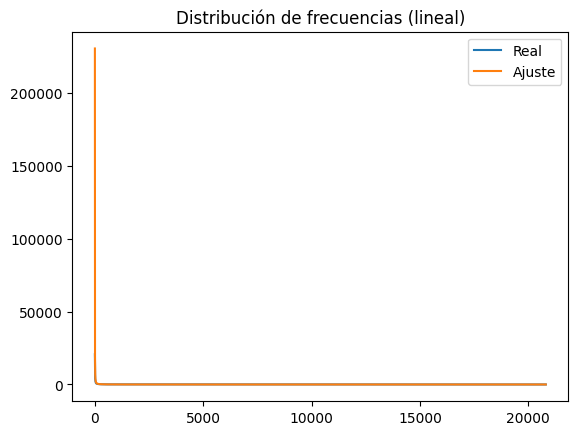

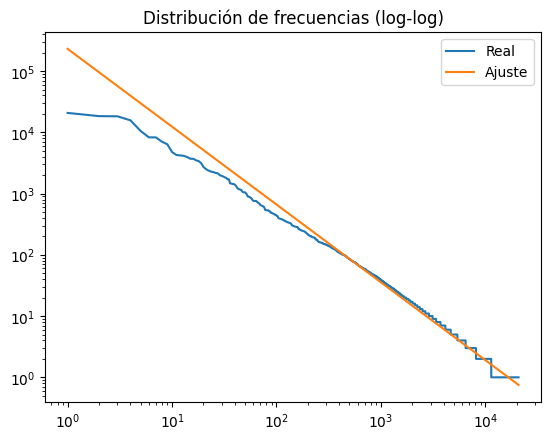

In [33]:
import matplotlib.pyplot as plt

fitted_log = m * log_ranks + y
fitted = np.exp(fitted_log)

# grafico lineal
plt.figure()
plt.plot(ranks, freqs, label="Real")
plt.plot(ranks, fitted, label="Ajuste")
plt.legend()
plt.title("Distribución de frecuencias (lineal)")
plt.show()

# grafico log
plt.figure()
plt.loglog(ranks, freqs, label="Real")
plt.loglog(ranks, fitted, label="Ajuste")
plt.legend()
plt.title("Distribución de frecuencias (log-log)")
plt.show()